<a href="https://colab.research.google.com/github/AntonioHallgass/corso_AI_2025/blob/main/esame_18.7/MetodiAIFisica_ApplicazioniFisicheML_2025_ProvaPratica_18_7_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova Pratica - Metodi AI per la fisica e Applicazioni Fisiche al ML
### 18.7.2026 - AA 2024/25 - Docenti: S. Giagu e A. Ciardiello

---

**Regole:**

*   **tempo a disposizione:** 3.0h

*   compilare con i vostri dati i campi della cella che segue e poi eseguire la cella verificando che i dati printati corrispondano.
*   risolvere i quesiti/compiti indicati nella cella *Descrizione del compito*.
*   una volta completato il compito scaricare il notebook in formato *.ipynb* e caricarlo **usando il google form**:
[consegna notebook](https://docs.google.com/forms/d/e/1FAIpQLSegMZ0wnHsenyzo473GV2TUn6ABnFKuJxEHd1Gf0DSMAAMEsA/viewform?usp=dialog)<p>


**NOTA:** una volta caricato e sottomesso il notebook non sono più possibili ulteriori modifiche.

In [1]:
#@ Dati Personali
import os

Nome = 'Stefano'  #@param {type: "string"}
Cognome = 'Giagu' #@param {type: "string"}
NumeroMatricola = 123456782 #@param {type: "number"}

if NumeroMatricola == 12345678:
  print('\033[1;31m Inserisci il numero di matricola corretto!!!!')
else:
  print('\033[1;31m Done')

 Done


# Descrizione del compito:

**Svolgere i seguenti quesiti:**

1. (Q1): scaricare il dataset MNIST nel modo che si ritiene più opportuno, e graficare un'immagine per ciascuna delle cifre da 0 a 9, formattando le immagini in una matrice di due righe per cinque immagini, riportando sopra ogni immagine la label associata;
2. (Q2): allenare un modello basato su architettura CNN che predica se l'immagine del numero in input è un numero pari o dispari. Allenare il modello per 20 epoche di training, salvando ad ogni epoca tutti i pesi del modello. NOTA: utilizzare 7000 immagini per il training, per mantenere i tempi di addestramento limitati;
3. (Q3): ripetere il task Q2, nelle stesse condizioni, scambiando nella rete neurale l'ordine tra attivazione e Conv2d e tra attivazione e Linear (*esempio: Conv2d, ReLU -->  ReLU, Conv2d*). Spiegare i risultati ottenuti;
4. (Q4): allenare altri 4 modelli con la stessa architettura usata in Q2, usando per e dei minibtach ciascuno una diversa inizializzazione dei pesi del campione di training. Stimare l'accuracy media e l'inceretezza sull'accuracy media dell'ensamble di modelli allenati in Q2 e Q4;
5. (Q5): graficare la dinamica di training dei modelli dell'ensamble (modello allenato in Q2 e modelli allenati in Q4), graficando la traiettoria di training di ciascun modello nello spazio PCA: per ogni modello graficare un punto nello spazio (PCA[0],PCA[1]) per ogni epoca di allenamento, colorando i punti di ciascuna epoca con una mappa di colori dal piu scuro (prima epoca) al più chiaro (ultima epoca). Commentare quanto ottenuto;
6. (Q6): prendere i pesi salvati del primo modello (quello allenato in Q2), e ripetere il calcolo della PCA, come nel punto Q5, per 3 volte, permutando ogni volta in modo casuale l'ordine delle epoche. Graficare le traiettorie ottenute nello spazio (PCA[0],PCA[1]). Spiegare quanto ottenuto.

* commentare opportunamente i risultati ottenuti in ogni punto.

# import

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import torch
from torch.utils.data import TensorDataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

In [4]:
%pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.7 MB/s eta 0:00:00


In [5]:
import time

In [6]:
from sklearn.model_selection import train_test_split

# load dati


In [7]:
train= pd.read_csv("sample_data/mnist_train_small.csv")
test = pd.read_csv("sample_data/mnist_test.csv")
train=np.array(train)
test=np.array(test)

In [8]:
y_train=np.array(train[:,0])
X_train=np.array(train[:,1:])
y_test=np.array(test[:,0])
X_test=np.array(test[:,1:])

In [9]:
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(19999, 784) (19999,) (9999, 784) (9999,)


[ 5 26  4 15 20  0  6  1 13  2]


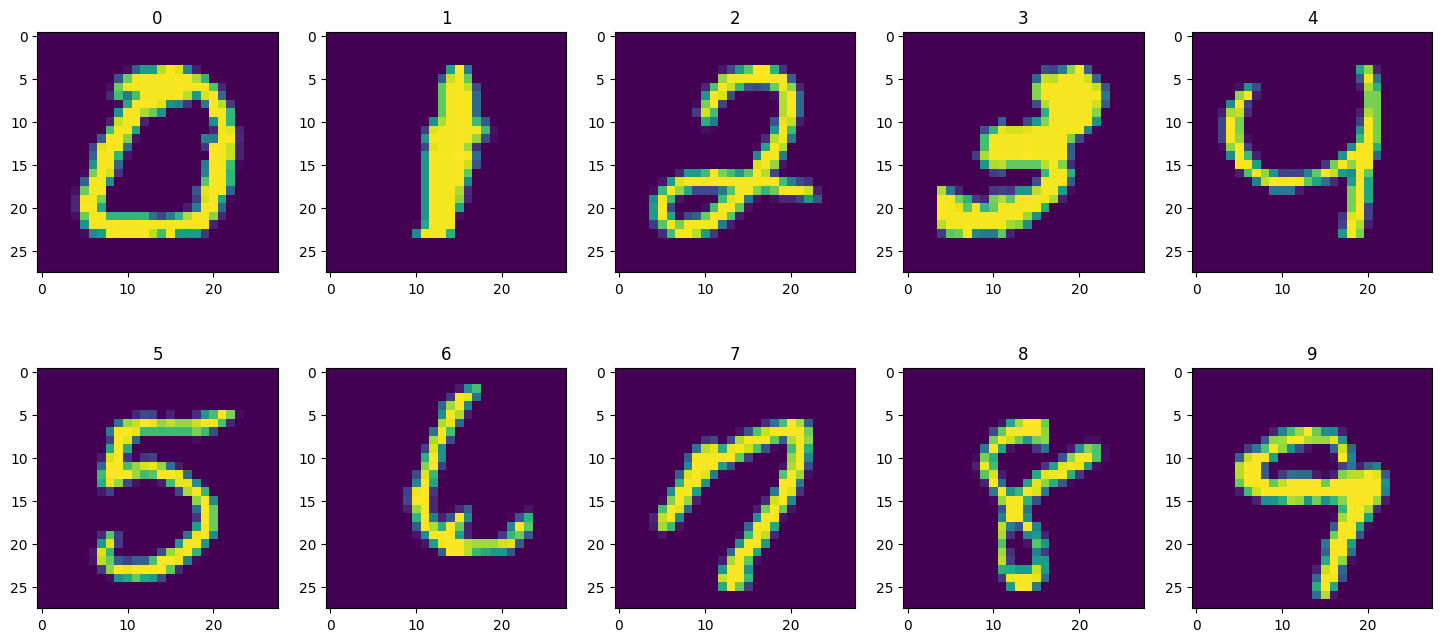

In [10]:
diversi,indici_diversi=np.unique(y_train,return_index=True)
print(indici_diversi)
counter=0
plt.figure(figsize=(18,8))
for i in iter(indici_diversi):
  counter+=1
  plt.subplot(2, 5, counter)
  img=X_train[i].reshape(28,28)
  plt.imshow(img)
  plt.title(f"{y_train[i]}")

# Preprocessing e cazzi

In [11]:
device=('cuda' if torch.cuda.is_available else 'cpu')
print(f"device={device}")

device=cuda


In [12]:
X_train,X_eval,y_train,y_eval=train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [13]:
y_train=y_train.reshape(-1,1)
X_train=X_train.reshape(-1,28,28)
y_test=y_test.reshape(-1,1)
X_test=X_test.reshape(-1,28,28)
y_eval=y_train.reshape(-1,1)
X_eval=X_train.reshape(-1,28,28)

X_train=torch.tensor(X_train, dtype=torch.float32)
y_train=torch.tensor(y_train, dtype=torch.float32)
X_test=torch.tensor(X_test, dtype=torch.float32)
y_test=torch.tensor(y_test, dtype=torch.float32)
X_eval=torch.tensor(X_eval, dtype=torch.float32)
y_eval=torch.tensor(y_eval, dtype=torch.float32)

X_train=X_train.to(device)
X_test=X_test.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)
y_eval=y_eval.to(device)
y_eval=y_eval.to(device)

train_ds=TensorDataset(X_train,y_train)
train_dl=DataLoader(train_ds,batch_size=32,shuffle=True)
test_ds=TensorDataset(X_test,y_test)
test_dl=DataLoader(test_ds,batch_size=32,shuffle=True)
eval_ds=TensorDataset(X_eval,y_eval)
eval_dl=DataLoader(eval_ds,batch_size=32,shuffle=True)


# Architettura CNN

In [14]:
class MyCNN(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv1=nn.Conv2d(1,8,kernel_size=4)
    self.conv2=nn.Conv2d(8,16,kernel_size=3)
    self.conv3=nn.Conv2d(16,32,kernel_size=2)
    self.relu=nn.ReLU()
    self.pool=nn.MaxPool2d(kernel_size=2)
    self.linear=nn.Linear(32*4*4,1)
    self.sigmoid=nn.Sigmoid()

  def forward(self,x):
    out=self.conv1(x)
    out=self.relu(out)
    out=self.pool(out)
    out=self.conv2(out)
    out=self.relu(out)
    out=self.pool(out)
    out=self.conv3(out)
    out=self.relu(out)
    out=self.linear(out.flatten(1))
    return self.sigmoid(out)

In [15]:
instance_cnn=MyCNN()
summary(instance_cnn.to(device), input_size=(1,28,28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 25, 25]             136
              ReLU-2            [-1, 8, 25, 25]               0
         MaxPool2d-3            [-1, 8, 12, 12]               0
            Conv2d-4           [-1, 16, 10, 10]           1,168
              ReLU-5           [-1, 16, 10, 10]               0
         MaxPool2d-6             [-1, 16, 5, 5]               0
            Conv2d-7             [-1, 32, 4, 4]           2,080
              ReLU-8             [-1, 32, 4, 4]               0
            Linear-9                    [-1, 1]             513
          Sigmoid-10                    [-1, 1]               0
Total params: 3,897
Trainable params: 3,897
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.01
Estimated Total

# Train


In [16]:
MyLoss=nn.BCELoss()
MyOptimizer=torch.optim.Adam(instance_cnn.parameters(),lr=8e-4)

In [17]:
xb,yb=next(iter(train_dl))

In [18]:
print(xb.shape,yb.shape)

torch.Size([32, 28, 28]) torch.Size([32, 1])


In [19]:
def train_cnn(model,Loss,Opt,train_dl,eval_dl,N_epochs=100):

  hist_loss=[]
  hist_vloss=[]

  for epoch in range(N_epochs):
    t0=time.time()
    total_loss=0
    total_vloss=0
    counter_train=0
    counter_eval=0

    model.train()
    for xb,yb in (train_dl):
      #xb=xb.to(device)
      #yb=yb.to(device)
      xb=xb.unsqueeze(1)
      counter_train+=1
      pred=model(xb)
      loss=Loss(pred,yb%2)
      total_loss+=loss.item()

      Opt.zero_grad()
      loss.backward()
      Opt.step()

    total_loss/=counter_train
    hist_loss.append(total_loss)

    model.eval()
    with torch.no_grad():
      for xb,yb in (eval_dl):
        # xb=xb.to(device)
        # yb=yb.to(device)
        xb=xb.unsqueeze(1)
        counter_eval+=1
        pred=model(xb)
        vloss=Loss(pred,yb%2)
        total_vloss+=vloss.item()

      total_vloss/=counter_eval
      hist_vloss.append(total_vloss)

    print(f"Epoch: {epoch}\tLoss: {total_loss}\tEvalLoss: {total_vloss}\tTime: {time.time()-t0}")
  return model,hist_loss,hist_vloss

In [20]:
instance_cnn,hist_loss,hist_vloss=train_cnn(instance_cnn,MyLoss,MyOptimizer,train_dl,eval_dl,N_epochs=20)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [ ]:
plt.plot(hist_loss,label="train")
plt.plot(hist_vloss,label="eval")
plt.legend()

In [ ]:
torch.save(instance_cnn,"./modellUno")

In [ ]:
modello_addestrato=torch.load("./modellUno", weights_only=False)

# Test

In [ ]:
test_loss=0
counter=0

modello_addestrato.eval()
with torch.no_grad():
    for xb,yb in (test_dl):
      counter+=1
      xb=xb.to(device)
      yb=yb.to(device)
      xb=xb.unsqueeze(1)
      pred=modello_addestrato(xb)
      loss=MyLoss(pred,yb%2)
      test_loss+=loss.item()

    test_loss/=counter
print(test_loss)

In [ ]:
pred=modello_addestrato(X_test.unsqueeze(1)).cpu().detach().numpy()
k=0
mask_errati=[]

for i in range(100):
  #print(f"numero: {y_test[i].item()}\tsarà dispari?: {pred[i]>0.5}")
  if (y_test[i].item()%2==0 and pred[i]>0.5) or (y_test[i].item()%2==1 and pred[i]<0.5):
    k+=1
    print(f"\nerratoooo({k})\n")
    mask_errati.append(i)
print(k)
#print(mask_errati)